In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import os

In [2]:
!pip install xgboost

^C


In [4]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

In [9]:
df = pd.read_csv("../data/processed_reviews.csv")

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,Sentiment,Clean_Review,Sentiment_Label
0,Lisa,/users/63c2d28aff751c001470ce46,US,1 review,2023-01-14T18:41:59.000Z,1,What happened to quality customer service?,"I ordered several items on Jan 2, this review ...","January 14, 2023",Negative,ordered several item jan review reference retu...,0
1,J Ellery,/users/4f5291a30000640001153f96,GB,6 reviews,2012-03-03T21:50:56.000Z,5,Best on the web,Never any problems.goods always arrive when st...,"March 03, 2012",Positive,never problemsgoods always arrive stated exell...,2
2,Heather Weber,/users/5d37078e6614abe3ab453adf,US,1 review,2019-07-23T13:12:41.000Z,3,Issues with online purchases,"Recently, I have been having issues with my or...","July 23, 2019",Neutral,recently issue order receiving item order rece...,1
3,Mrs Lowe,/users/5666ab6d0000ff0001f14958,GB,2 reviews,2015-12-08T10:07:54.695Z,5,Excellent as always,Very good.,NaN,Positive,good,2
4,Lolo Paz,/users/5d8732fb681610d90db66d2e,US,2 reviews,2019-09-22T08:41:50.000Z,4,Ive been shopping with amazon for…,Ive been shopping with amazon for almost a yea...,"September 22, 2019",Positive,ive shopping amazon almost year get delivery a...,2


In [11]:
X = df['Clean_Review']

y = df['Sentiment_Label']

In [12]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [16]:
y_pred = xgb_model.predict(X_test)

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9471221338324755


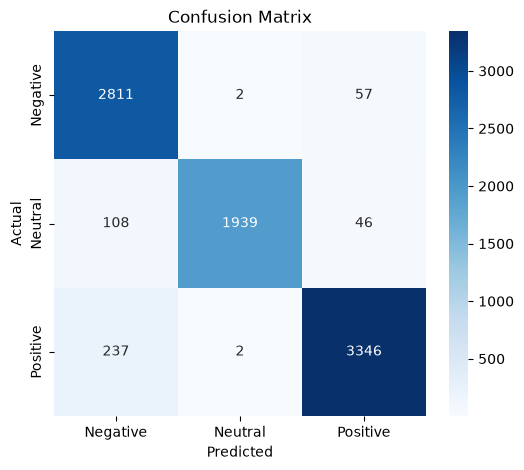

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.89      0.98      0.93      2870
     Neutral       1.00      0.93      0.96      2093
    Positive       0.97      0.93      0.95      3585

    accuracy                           0.95      8548
   macro avg       0.95      0.95      0.95      8548
weighted avg       0.95      0.95      0.95      8548



In [20]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.9502683657744214
Recall    : 0.9471221338324755
F1 Score  : 0.9475134324110055


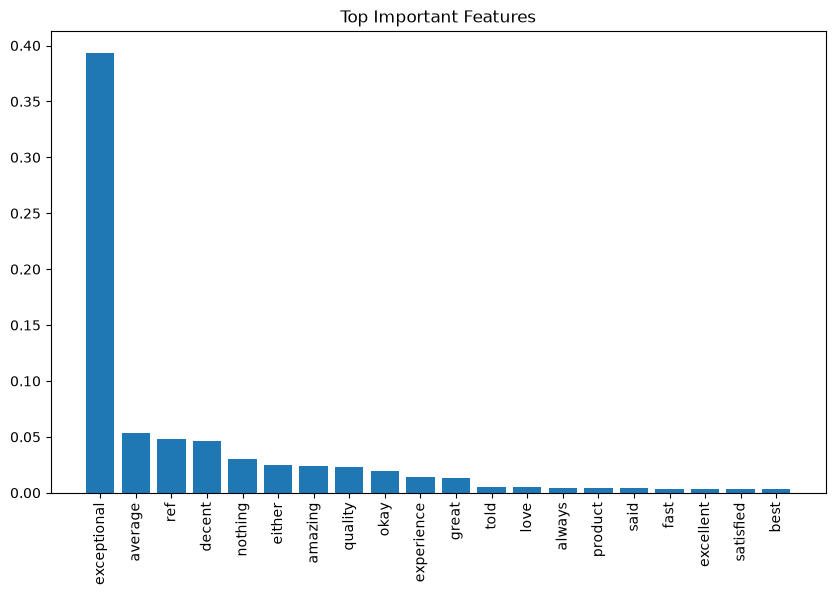

In [22]:
importance = xgb_model.feature_importances_

indices = np.argsort(importance)[::-1]

feature_names = tfidf.get_feature_names_out()
top_n = 20

plt.figure(figsize=(10,6))

plt.bar(
    range(top_n),
    importance[indices[:top_n]]
)

plt.xticks(
    range(top_n),
    feature_names[indices[:top_n]],
    rotation=90
)

plt.title("Top Important Features")

plt.show()

In [23]:
os.makedirs("../models", exist_ok=True)
with open("../models/tfidf_xgb.pkl","wb") as file:
    pickle.dump(tfidf,file)

with open("../models/xgb_model.pkl","wb") as file:
    pickle.dump(xgb_model,file)